
# Orthogonal Matrices and QR Decomposition

Ringkasan Chapter 9 membahas orthogonal matrix, Gram-Schmidt, dan QR decomposition. Chapter ini menekankan bahwa QR decomposition merupakan salah satu dekomposisi terpenting dalam linear algebra karena digunakan dalam matrix inverse, least squares, dan eigendecomposition.



## Tujuan Pembelajaran

- Memahami orthogonal matrix.
- Memahami hubungan transpose dan inverse pada orthogonal matrix.
- Memahami Gram-Schmidt procedure.
- Memahami QR decomposition.
- Memahami ukuran dan rank dari matriks Q dan R.
- Memahami alasan R berbentuk upper triangular.
- Memahami hubungan QR decomposition dengan matrix inverse.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



# Orthogonal Matrices

Orthogonal matrix adalah matriks khusus yang memiliki dua sifat utama:

1. Semua kolom saling orthogonal.
2. Setiap kolom memiliki norm = 1.

### Rumus Orthogonal Matrix

$$
q_i^T q_j =
\begin{cases}
0, & i \ne j \\
1, & i = j
\end{cases}
$$

Keterangan:

- $q_i$ = kolom ke-i
- $q_j$ = kolom ke-j
- Dot product antar kolom berbeda bernilai 0.
- Dot product kolom dengan dirinya sendiri bernilai 1.



### Hubungan Orthogonal Matrix dengan Identity Matrix

Jika seluruh kolom orthogonal dan memiliki panjang 1, maka:

$$
Q^TQ = I
$$

Keterangan:

- $Q^T$ = transpose dari Q
- $I$ = identity matrix

Persamaan ini sangat penting karena menunjukkan bahwa:

$$
Q^{-1} = Q^T
$$

Artinya inverse orthogonal matrix cukup dihitung dengan transpose.


In [2]:

Q = np.array([[1,-1],[1,1]]) / np.sqrt(2)

print("Q^T Q")
print(Q.T @ Q)

print("\nQ^-1")
print(np.linalg.inv(Q))

print("\nQ^T")
print(Q.T)


Q^T Q
[[1.00000000e+00 2.23711432e-17]
 [2.23711432e-17 1.00000000e+00]]

Q^-1
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Q^T
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]



# Gram-Schmidt Procedure

Gram-Schmidt adalah metode untuk mengubah matriks biasa menjadi orthogonal matrix.

Ide utamanya adalah:

1. Ambil satu kolom.
2. Hilangkan komponen yang searah dengan kolom sebelumnya.
3. Normalisasi menjadi panjang 1.
4. Ulangi untuk seluruh kolom.

Hasil akhirnya adalah matriks orthogonal Q.



### Konsep Orthogonalisasi

Jika terdapat vektor $v$ dan basis orthogonal $q$, maka komponen proyeksi dapat dihitung menggunakan:

$$
\text{proj}_q(v)
=
\frac{q^Tv}{q^Tq}q
$$

Kemudian komponen orthogonal diperoleh melalui:

$$
v^* = v - \text{proj}_q(v)
$$

Vektor $v^*$ inilah yang digunakan dalam proses Gram-Schmidt.


In [3]:

A = np.random.randn(4,4)

Q,_ = np.linalg.qr(A)

print("Orthogonality check")
print(np.round(Q.T @ Q,4))


Orthogonality check
[[ 1. -0. -0.  0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1. -0.]
 [ 0.  0. -0.  1.]]



# QR Decomposition

QR decomposition memecah matriks A menjadi dua matriks:

$$
A = QR
$$

Keterangan:

- $Q$ = orthogonal matrix
- $R$ = upper triangular matrix

QR decomposition merupakan hasil dari proses orthogonalisasi seperti Gram-Schmidt.



### Menghitung R

Karena:

$$
A = QR
$$

Kalikan kedua sisi dengan $Q^T$:

$$
Q^TA = Q^TQR
$$

Karena:

$$
Q^TQ = I
$$

Maka:

$$
R = Q^TA
$$

Ini merupakan rumus utama untuk memperoleh matriks R.


In [4]:

A = np.random.randn(6,6)

Q,R = np.linalg.qr(A)

print("Reconstruction Error")
print(np.linalg.norm(A - Q@R))


Reconstruction Error
1.7779316226404553e-15


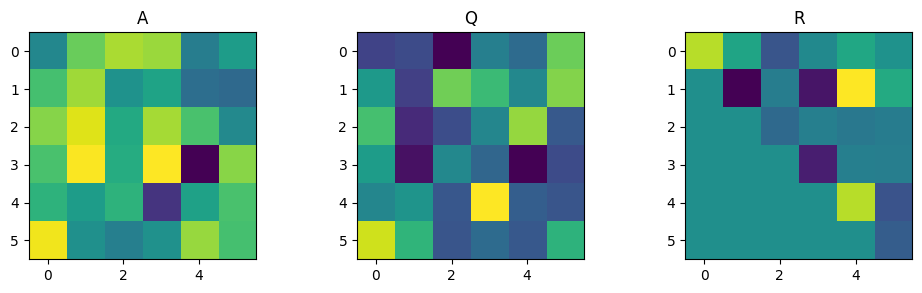

In [5]:

A = np.random.randn(6,6)
Q,R = np.linalg.qr(A)

fig,ax = plt.subplots(1,3,figsize=(10,3))

ax[0].imshow(A)
ax[0].set_title("A")

ax[1].imshow(Q)
ax[1].set_title("Q")

ax[2].imshow(R)
ax[2].set_title("R")

plt.tight_layout()
plt.show()



# Ukuran Matriks Q dan R

Ukuran Q dan R bergantung pada ukuran matriks A.

Secara umum:

### Jika A square

$$
A_{M\times M}
=
Q_{M\times M}
R_{M\times M}
$$

### Jika A tall

$$
M>N
$$

Terdapat dua pilihan:

1. Reduced QR
2. Complete QR

Pada reduced QR, jumlah kolom Q mengikuti jumlah kolom A.

Pada complete QR, Q dapat menjadi matriks square penuh.


In [6]:

A = np.random.randn(8,4)

Q_red,R_red = np.linalg.qr(A,mode='reduced')
Q_full,R_full = np.linalg.qr(A,mode='complete')

print("Reduced Q:",Q_red.shape)
print("Reduced R:",R_red.shape)

print("\nFull Q:",Q_full.shape)
print("Full R:",R_full.shape)


Reduced Q: (8, 4)
Reduced R: (4, 4)

Full Q: (8, 8)
Full R: (8, 4)



# Mengapa R Upper Triangular?

Chapter menjelaskan bahwa:

$$
R = Q^TA
$$

Karena kolom-kolom pada Q dibentuk secara bertahap dari kiri ke kanan menggunakan proses orthogonalisasi, maka banyak dot product pada bagian bawah matriks akan bernilai nol.

Akibatnya:

$$
R =
\begin{bmatrix}
* & * & * \\
0 & * & * \\
0 & 0 & *
\end{bmatrix}
$$

Sehingga R selalu berbentuk upper triangular.


In [7]:

A = np.random.randn(5,5)

_,R = np.linalg.qr(A)

print(np.round(R,3))


[[-3.207  1.22  -0.203  0.1    0.331]
 [ 0.    -1.627  1.468 -0.424 -0.493]
 [ 0.     0.     1.977 -1.235  1.444]
 [ 0.     0.     0.    -1.086  0.663]
 [ 0.     0.     0.     0.    -0.385]]



# QR dan Matrix Inverse

Salah satu aplikasi penting QR decomposition adalah menghitung inverse secara lebih stabil.

Mulai dari:

$$
A = QR
$$

Lakukan inverse pada kedua sisi:

$$
A^{-1}
=
(QR)^{-1}
$$

Menggunakan aturan LIVE EVIL:

$$
A^{-1}
=
R^{-1}Q^{-1}
$$

Karena:

$$
Q^{-1}=Q^T
$$

Maka:

$$
A^{-1}
=
R^{-1}Q^T
$$

Pendekatan ini sering lebih stabil secara numerik dibandingkan metode inverse biasa.


In [8]:

A = np.random.randn(4,4)

Q,R = np.linalg.qr(A)

Ainv_qr = np.linalg.inv(R) @ Q.T
Ainv_np = np.linalg.inv(A)

print("Difference")
print(np.linalg.norm(Ainv_qr - Ainv_np))


Difference
1.0765800669398624e-15



# Ringkasan Konsep Penting

| Konsep | Penjelasan |
|----------|----------|
| Orthogonal Matrix | Kolom saling orthogonal dan norm = 1 |
| Orthogonal Property | $Q^TQ=I$ |
| Inverse Orthogonal Matrix | $Q^{-1}=Q^T$ |
| Gram-Schmidt | Metode orthogonalisasi |
| QR Decomposition | $A=QR$ |
| R Matrix | Selalu upper triangular |
| Reduced QR | Q lebih kecil |
| Complete QR | Q square penuh |
| QR Inverse | $A^{-1}=R^{-1}Q^T$ |



# Kesimpulan

Chapter ini memperkenalkan orthogonal matrix dan QR decomposition sebagai salah satu dekomposisi paling penting dalam linear algebra. Orthogonal matrix memiliki sifat unik yaitu transpose-nya sama dengan inverse-nya. Melalui Gram-Schmidt procedure, matriks biasa dapat diubah menjadi orthogonal matrix.

QR decomposition memecah matriks menjadi orthogonal matrix Q dan upper triangular matrix R. Selain digunakan untuk analisis matriks, QR decomposition juga memberikan pendekatan yang lebih stabil untuk menghitung inverse dan menjadi dasar bagi berbagai metode machine learning serta numerical computation.
